LAB 1: Single Layer Perceptron

OBJECTIVE 1: Implement a single-layer perceptron for binary classification (AND/OR gate) from scratch and visualize the decision boundaries.

THEORY:
A single layer perceptron is the simplest form of an artificial neural network.
It is mainly used for binary classification problems where the output is either 0 or 1.

It consists of the following components:
- Input values
- Weights
- Bias
- Activation function

WORKING OF SINGLE LAYER PERCEPTRON:

- The input values are multiplied by their corresponding weights.

- All weighted inputs are added together.

- A bias value is added to the sum.

- The result is passed through an activation function.

- The final output is either 0 or 1.

MATHEMATICAL REPRESENTATION:

y = w1x1 + w2x2 + b

If y >= 0, output = 1
If y < 0, output = 0

This decision is made using a step (threshold) activation function.

IMPORTANCE OF SINGLE LAYER PERCEPTRON:

- Foundation of Neural Networks:
The single layer perceptron is the base model for understanding neural networks and deep learning concepts.

- Simple and Easy to Understand:
It uses basic mathematics and logic, making it suitable for beginners in machine learning.

- Solves Linearly Separable Problems:
It can correctly classify problems like AND and OR logic gates.

- Introduces Learning Process:
It helps in understanding how weights and bias are updated during training.

- Fast and Efficient:
Training is quick because of simple calculations and fewer parameters.

- Educational Importance:
It is widely used in academic labs to explain basic neural network concepts.

ALGORITHM:

- Initialize all weights to 0

- Initialize bias to 0

- Set learning rate and number of epochs

- Repeat the following steps for each epoch

- For each training input

    - Calculate the weighted sum
        - y = w1x1 + w2x2 + bias

- Apply step activation function

    - If y >= 0, output = 1

    - If y < 0, output = 0

- Calculate error
    - error = actual output - predicted output

- Update weights
    - w = w + learning_rate * error * input

- Update bias
    - bias = bias + learning_rate * error

- Stop training after all epochs are completed

- Use final weights and bias for prediction

SOURCE CODE:

Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Step Activation Function

In [2]:
def step_function(value):
    if value >= 0:
        return 1
    else:
        return 0

Training Function

In [3]:
def train_perceptron(X, y, learning_rate=0.1, epochs=20):

    # Initialize weights and bias
    w1 = 0
    w2 = 0
    bias = 0

    # Training process
    for epoch in range(epochs):
        for i in range(len(X)):

            x1 = X[i][0]
            x2 = X[i][1]

            # Calculate linear output
            linear_output = (w1 * x1) + (w2 * x2) + bias

            # Apply activation function
            y_pred = step_function(linear_output)

            # Calculate error
            error = y[i] - y_pred

            # Update weights and bias
            w1 = w1 + learning_rate * error * x1
            w2 = w2 + learning_rate * error * x2
            bias = bias + learning_rate * error

    return w1, w2, bias

Prediction Function

In [4]:
def predict(X, w1, w2, bias):
    outputs = []
    for i in range(len(X)):
        linear_output = (w1 * X[i][0]) + (w2 * X[i][1]) + bias
        outputs.append(step_function(linear_output))
    return outputs

AND Gate Implementation

In [5]:
# AND gate dataset
X_and = np.array([[0,0], [0,1], [1,0], [1,1]])
y_and = np.array([0, 0, 0, 1])

# Train perceptron
w1, w2, bias = train_perceptron(X_and, y_and)

# Prediction
print("AND Gate Output:")
print(predict(X_and, w1, w2, bias))

AND Gate Output:
[0, 0, 0, 1]


OR Gate Implementation

In [6]:
# OR gate dataset
X_or = np.array([[0,0], [0,1], [1,0], [1,1]])
y_or = np.array([0, 1, 1, 1])

# Train perceptron
w1, w2, bias = train_perceptron(X_or, y_or)

# Prediction
print("OR Gate Output:")
print(predict(X_or, w1, w2, bias))

OR Gate Output:
[0, 1, 1, 1]


Decision Boundary Plot

In [7]:
def plot_decision_boundary(X, y, w1, w2, bias, title):
    x_values = np.linspace(-0.5, 1.5, 100)
    y_values = -(w1 * x_values + bias) / w2

    plt.scatter(X[:,0], X[:,1], c=y)
    plt.plot(x_values, y_values)
    plt.xlabel("Input 1")
    plt.ylabel("Input 2")
    plt.title(title)
    plt.show()

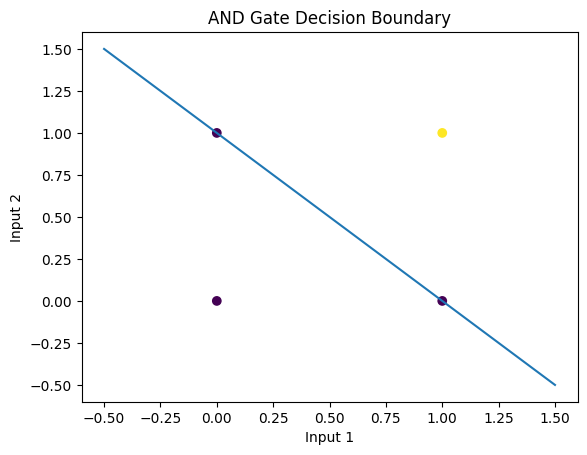

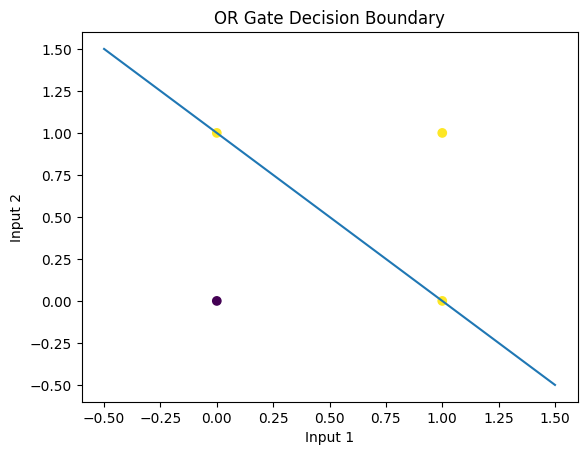

In [8]:
plot_decision_boundary(X_and, y_and, w1, w2, bias, "AND Gate Decision Boundary")
plot_decision_boundary(X_or, y_or, w1, w2, bias, "OR Gate Decision Boundary")

OBJECTIVE 2: Implement a binary moon classification, "limitation test" - show that a singlelayer perceptron cannot handle non-linear separation. Use scikit-learn moon generator.

THEORY:
-  LIMITATIONS OF SLPs:
    - Can only solve linearly separable problems

    - Cannot handle non-linear decision boundaries

    - Fails to classify complex patterns such as:

        - XOR problem

        - Moon-shaped data

        - Circular data

ALGORITHM:

- Generate non-linear moon dataset using make_moons

- Initialize weights and bias to 0

- Set learning rate and number of epochs

- For each epoch:

    - For each input sample:

        - Calculate weighted sum: y = w1x1 + w2x2 + bias

    - Apply step activation function:

        - If y >= 0 → output = 1

        - Else → output = 0

    - Calculate error = actual output - predicted output

    - Update weights and bias using perceptron learning rule

- After training, use final weights and bias to predict

- Plot the dataset and show misclassification

Note: This will fail to separate moon data correctly because it is non-linear.

SOURCE CODE:

IMPORT LIBRARIES

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# For Jupyter inline plotting
%matplotlib inline

GENERATE MOON DATA

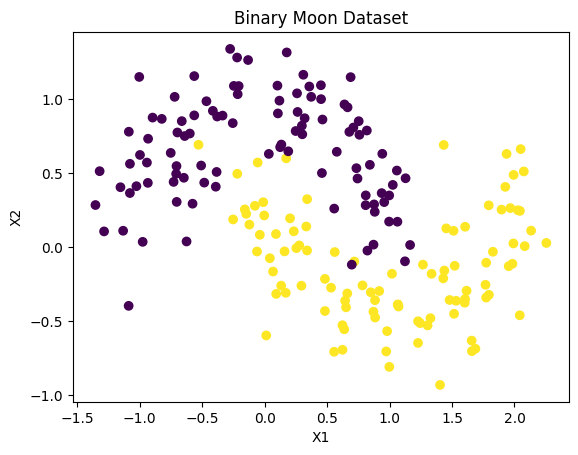

In [10]:
# Generate binary moon dataset
X, y = make_moons(n_samples=200, noise=0.2, random_state=0)

# Plot the data
plt.scatter(X[:,0], X[:,1], c=y)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Binary Moon Dataset")
plt.show()

STEP ACTIVATION FUNCTION

In [11]:
def step_function(value):
    if value >= 0:
        return 1
    else:
        return 0

TRAIN SINGLE-LAYER PERCEPTRON

In [12]:
def train_perceptron(X, y, learning_rate=0.01, epochs=20):
    w1, w2, bias = 0, 0, 0  # initialize weights and bias
    
    for _ in range(epochs):
        for i in range(len(X)):
            x1, x2 = X[i]
            linear_output = w1*x1 + w2*x2 + bias
            y_pred = step_function(linear_output)
            error = y[i] - y_pred
            
            # Update weights and bias
            w1 += learning_rate * error * x1
            w2 += learning_rate * error * x2
            bias += learning_rate * error
            
    return w1, w2, bias

PREDICTION FUNCTION

In [13]:
def predict(X, w1, w2, bias):
    y_pred = []
    for i in range(len(X)):
        output = step_function(w1*X[i][0] + w2*X[i][1] + bias)
        y_pred.append(output)
    return np.array(y_pred)

TRAIN THE PERCEPTRON

In [14]:
# Train perceptron on moon data
w1, w2, bias = train_perceptron(X, y, learning_rate=0.01, epochs=20)

# Predict
y_pred = predict(X, w1, w2, bias)

PLOT DECISION BOUNDARY

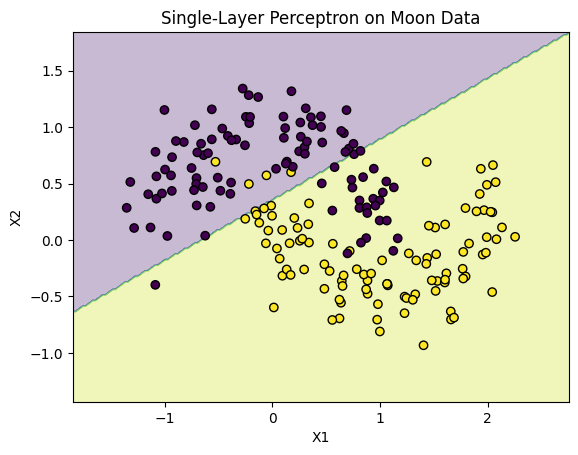

In [15]:
def plot_decision_boundary(X, y, w1, w2, bias, title):
    x_min, x_max = X[:,0].min() - 0.5, X[:,0].max() + 0.5
    y_min, y_max = X[:,1].min() - 0.5, X[:,1].max() + 0.5
    
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = predict(grid, w1, w2, bias)
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
    plt.title(title)
    plt.xlabel("X1")
    plt.ylabel("X2")
    plt.show()

# Show decision boundary
plot_decision_boundary(X, y, w1, w2, bias, "Single-Layer Perceptron on Moon Data")

OBJECTIVE 3: Implement a MLE and MAP estimation

THEORY:

MAXIMUM LIKELIHOOD ESTIMATION (MLE):

- Estimates parameters that maximize the probability of observing the given data.

- Uses only the data, no prior knowledge.

- Example: For data from a normal distribution, the MLE of mean μ is the sample average.

MAXIMUM A POSTERIORI (MAP):

- Estimates parameters that maximize the posterior probability, considering data and prior knowledge.

- Useful when data is limited or noisy.

Key Difference:

-MLE = data only

-MAP = data + prior knowledge

ALGORITHM:

- Collect data samples

- MLE:

    - Compute likelihood of data for different parameter values

    - Choose the parameter that maximizes the likelihood

- MAP:

    - Define a prior for the parameter

    - Compute posterior = likelihood × prior

- Choose the parameter that maximizes the posterior

- Output the estimated parameter

SOURCE CODE:

IMPORT LIBRARIES

In [16]:
import numpy as np
import matplotlib.pyplot as plt

GENERATE SAMPLE DATA

In [17]:
# Generate sample data from normal distribution
np.random.seed(0)
true_mu = 5       # True mean
sigma = 2         # Known standard deviation
n_samples = 20

data = np.random.normal(loc=true_mu, scale=sigma, size=n_samples)

print("Sample Data:", data)

Sample Data: [8.52810469 5.80031442 6.95747597 9.4817864  8.73511598 3.04544424
 6.90017684 4.69728558 4.7935623  5.821197   5.28808714 7.90854701
 6.52207545 5.24335003 5.88772647 5.66734865 7.98815815 4.58968347
 5.6261354  3.29180852]


MLE ESTIMATION

In [18]:
# MLE estimate of mean
mle_mu = np.mean(data)
print("MLE Estimate of mean:", mle_mu)

MLE Estimate of mean: 6.138669185891269


MAP ESTIMATION

In [19]:
# MAP estimate: assuming prior mu ~ N(prior_mu, prior_sigma^2)
prior_mu = 4       # Prior mean
prior_sigma = 1    # Prior std

# MAP formula for Gaussian with known variance:
# MAP_mu = (sigma^2 * prior_mu + n_samples * prior_sigma^2 * sample_mean) / (n_samples * prior_sigma^2 + sigma^2)
map_mu = (sigma**2 * prior_mu + n_samples * prior_sigma**2 * mle_mu) / (n_samples * prior_sigma**2 + sigma**2)

print("MAP Estimate of mean:", map_mu)

MAP Estimate of mean: 5.782224321576057


VISUALIZATION

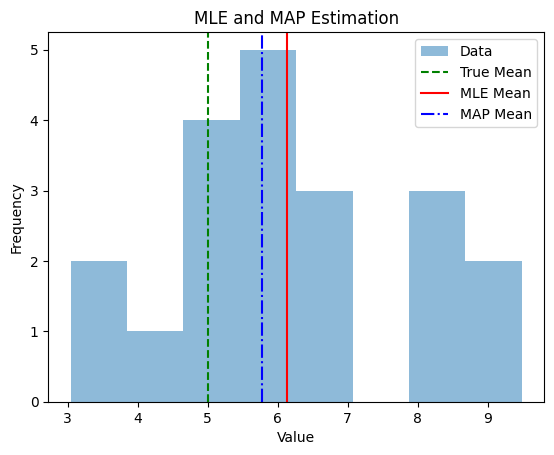

In [20]:
# Plot prior, data mean, MLE, and MAP
plt.hist(data, bins=8, alpha=0.5, label="Data")
plt.axvline(true_mu, color='g', linestyle='--', label="True Mean")
plt.axvline(mle_mu, color='r', linestyle='-', label="MLE Mean")
plt.axvline(map_mu, color='b', linestyle='-.', label="MAP Mean")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("MLE and MAP Estimation")
plt.legend()
plt.show()

RESULTS:

- Objective 1: Single-layer perceptron correctly learned AND and OR gates with straight-line decision boundaries.

- Objective 2: Perceptron failed to classify the non-linear moon dataset, showing its limitation.

- Objective 3: MLE estimated parameters based on data, while MAP adjusted estimates using prior knowledge.

CONCLUSION:

- Single-layer perceptrons work well for linearly separable problems but fail for non-linear data.

- MLE is purely data-driven, whereas MAP incorporates prior information for better estimates when data is limited.

- Overall, the lab demonstrates the strengths and limitations of simple perceptrons and highlights basic parameter estimation techniques.